# EpiSentinel — SARI Severity Prediction

 Phase 1: Data Understanding

# Research question
Can demographic and clinical information available around hospital
presentation/admission predict mortality among patients with Severe
Acute Respiratory Infection (SARI)?

# Initial target
`EVOLUCAO`

- 1 = Recovery
- 2 = Death
- 3 = Death from other causes
- 9 = Unknown

For the initial binary prediction problem, only outcomes 1 and 2
will be considered.

## PHASE 1. Imports and Data Understanding

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
Path.cwd()

PosixPath('/Users/amala/Desktop/MAIN/Episentinel-SARI-AI/notebooks')

In [5]:
DATA_PATH = Path("/Users/amala/Desktop/MAIN/Episentinel-SARI-AI/data/INFLUD24-23-03-2026.csv")
print(DATA_PATH)

/Users/amala/Desktop/MAIN/Episentinel-SARI-AI/data/INFLUD24-23-03-2026.csv


In [6]:
DATA_PATH.exists()

True

In [ ]:
# Load dataset
df = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="latin1",
    low_memory=False
)

In [9]:
df.shape

(267986, 194)

In [10]:
df.head()

,NU_NOTIFIC,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,...,VG_OMS,VG_OMSOUT,VG_LIN,VG_MET,VG_METOUT,VG_DTRES,VG_ENC,VG_REINF,VG_CODEST,REINF
0,31725016651631,2024-08-29T00:00:00.000Z,35,2024-08-28T00:00:00.000Z,35,PR,09RS FOZ DO IGUACU,1363.0,FOZ DO IGUACU,410830.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,31717520754098,2024-06-04T00:00:00.000Z,23,2024-05-28T00:00:00.000Z,22,SC,FLORIANOPOLIS,1476.0,FLORIANOPOLIS,420540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,31706909530914,2024-02-02T00:00:00.000Z,5,2024-01-23T00:00:00.000Z,4,MG,DIAMANTINA,1450.0,MINAS NOVAS,314180.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,31720790225526,2024-07-09T00:00:00.000Z,28,2024-07-03T00:00:00.000Z,27,BA,NUCLEO REGIONAL DE SAUDE SUDOESTE,1398.0,BARRA DO CHOCA,290290.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
4,31720694521471,2024-07-10T00:00:00.000Z,28,2024-07-07T00:00:00.000Z,28,SE,REGIONAL ARACAJU,2056.0,ARACAJU,280030.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [14]:
columns=df.columns.tolist()
print(columns)

['NU_NOTIFIC', 'DT_NOTIFIC', 'SEM_NOT', 'DT_SIN_PRI', 'SEM_PRI', 'SG_UF_NOT', 'ID_REGIONA', 'CO_REGIONA', 'ID_MUNICIP', 'CO_MUN_NOT', 'CS_SEXO', 'DT_NASC', 'NU_IDADE_N', 'TP_IDADE', 'COD_IDADE', 'CS_GESTANT', 'CS_RACA', 'CS_ETINIA', 'CS_ESCOL_N', 'ID_PAIS', 'CO_PAIS', 'SG_UF', 'ID_RG_RESI', 'CO_RG_RESI', 'ID_MN_RESI', 'CO_MUN_RES', 'CS_ZONA', 'NOSOCOMIAL', 'AVE_SUINO', 'FEBRE', 'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO', 'OUTRO_SIN', 'OUTRO_DES', 'FATOR_RISC', 'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA', 'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE', 'RENAL', 'OBESIDADE', 'OBES_IMC', 'OUT_MORBI', 'MORB_DESC', 'TABAG', 'VACINA', 'DT_UT_DOSE', 'MAE_VAC', 'DT_VAC_MAE', 'M_AMAMENTA', 'DT_DOSEUNI', 'DT_1_DOSE', 'DT_2_DOSE', 'ANTIVIRAL', 'TP_ANTIVIR', 'OUT_ANTIV', 'DT_ANTIVIR', 'HOSPITAL', 'DT_INTERNA', 'SG_UF_INTE', 'ID_RG_INTE', 'CO_RG_INTE', 'ID_MN_INTE', 'CO_MU_INTE', 'NM_UN_INTE', 'UTI', 'DT_ENTUTI', 'DT_SAIDUTI', '

In [ ]:
df["EVOLUCAO"].value_counts(dropna=False) # target variable differnt types

EVOLUCAO
1.0    219705
2.0     20730
NaN     14909
3.0      8057
9.0      4585
Name: count, dtype: int64

In [ ]:
# The Percentage of types in target variable
df["EVOLUCAO"].value_counts(
    normalize=True,
    dropna=False
).mul(100).round(2)

EVOLUCAO
1.0    81.98
2.0     7.74
NaN     5.56
3.0     3.01
9.0     1.71
Name: proportion, dtype: float64

In [ ]:
# we pick two types of targets Recovery vs Death:
df_model = df[df["EVOLUCAO"].isin([1, 2])].copy()
df_model

,NU_NOTIFIC,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,...,VG_OMS,VG_OMSOUT,VG_LIN,VG_MET,VG_METOUT,VG_DTRES,VG_ENC,VG_REINF,VG_CODEST,REINF
0,31725016651631,2024-08-29T00:00:00.000Z,35,2024-08-28T00:00:00.000Z,35,PR,09RS FOZ DO IGUACU,1363.0,FOZ DO IGUACU,410830.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
1,31717520754098,2024-06-04T00:00:00.000Z,23,2024-05-28T00:00:00.000Z,22,SC,FLORIANOPOLIS,1476.0,FLORIANOPOLIS,420540.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
3,31720790225526,2024-07-09T00:00:00.000Z,28,2024-07-03T00:00:00.000Z,27,BA,NUCLEO REGIONAL DE SAUDE SUDOESTE,1398.0,BARRA DO CHOCA,290290.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
5,31716914789687,2024-03-26T00:00:00.000Z,13,2024-03-26T00:00:00.000Z,13,ES,METROPOLITANA,1510.0,VILA VELHA,320520.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
6,31734353754928,2024-12-16T00:00:00.000Z,51,2024-12-10T00:00:00.000Z,50,PR,02RS METROPOLITANA,1356.0,CURITIBA,410690.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267981,31728311955389,2024-10-07T00:00:00.000Z,41,2024-10-05T00:00:00.000Z,40,PR,10RS CASCAVEL,1364.0,CASCAVEL,410480.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
267982,31719505826742,2024-06-22T00:00:00.000Z,25,2024-06-19T00:00:00.000Z,25,RS,002 CRS,1607.0,PORTO ALEGRE,431490.0,...,NaN,NaN,NaN,3.0,NaN,26/06/2024,3.0,NaN,2237571.0,2
267983,31720025591166,2024-07-03T00:00:00.000Z,27,2024-03-01T00:00:00.000Z,9,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
267984,31733924358159,2024-12-11T00:00:00.000Z,50,2024-06-27T00:00:00.000Z,26,SP,GVE I CAPITAL,1331.0,SAO PAULO,355030.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [19]:
df_model.shape

(240435, 194)

In [ ]:
df_model["EVOLUCAO"].value_counts()


EVOLUCAO
1.0    219705
2.0     20730
Name: count, dtype: int64

In [ ]:
# renamed the target variable to target_death
df_model["target_death"] = (
    df_model["EVOLUCAO"] == 2
).astype(int)

In [22]:
df_model["target_death"]

0         1
1         0
3         0
5         0
6         0
         ..
267981    0
267982    0
267983    0
267984    0
267985    1
Name: target_death, Length: 240435, dtype: int64

In [ ]:
df_model["target_death"].value_counts() # 0 is recovered and 1 is death

target_death
0    219705
1     20730
Name: count, dtype: int64

 
### shows that the dataset is highly unbalanced so for future evaluation accuracy is not a good metric to use.

In [ ]:
df_model["target_death"].value_counts(normalize=True).mul(100).round(2) 

target_death
0    91.38
1     8.62
Name: proportion, dtype: float64

NOTES:

Raw dataset
267,986 records
      
Outcome = EVOLUCAO
      
Keep only recovery/death
      
Binary target

0 = Recovery
1 = Death

### Using information available at or around hospital admission, can we predict whether a SARI patient will die?
That means every column must answer one question:
"Would I realistically know this when the patient is admitted?"

If no → don't give it to the model.

### Feature Availability and Leakage Audit

Prediction time: around hospital admission.

Features will be divided into:

1. **USE** — reasonably available at presentation/admission.
2. **POSSIBLE LATER** — clinically useful but may only become available after admission.
3. **EXCLUDE / LEAKAGE** — contains information about events occurring after the prediction point or directly reveals the outcome.

In [ ]:
#These aren't arbitrary. The dictionary explicitly describes variables such as dyspnoea, respiratory discomfort and oxygen saturation <95% as presenting symptoms.     dicionario-de-dados-2019-a-2025
#It also contains pre-existing risk factors such as cardiovascular disease, diabetes, neurological disease and chronic lung disease.     dicionario-de-dados-2019-a-2025
#And age is represented by NU_IDADE_N together with TP_IDADE, where the latter tells us whether the numerical age is in days, months or years.

candidate_features = [
    # Demographics
    "CS_SEXO",
    "NU_IDADE_N",
    "TP_IDADE",
    "CS_GESTANT",
    "CS_RACA",

    # Symptoms
    "FEBRE",
    "TOSSE",
    "GARGANTA",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
    "DIARREIA",
    "VOMITO",
    "DOR_ABD",
    "FADIGA",
    "PERD_OLFT",
    "PERD_PALA",

    # Comorbidities / risk factors
    "CARDIOPATI",
    "HEMATOLOGI",
    "SIND_DOWN",
    "HEPATICA",
    "ASMA",
    "DIABETES",
    "NEUROLOGIC",
    "PNEUMOPATI",
    "IMUNODEPRE",
    "RENAL",
    "OBESIDADE",
    "TABAG",

]

In [ ]:
#checking if the actually the features from candidatefeatures(demographics+symptoms+risks factors) exist in the dataset
missing_features = [
    col for col in candidate_features
    if col not in df_model.columns
]

missing_features

[]

### filtering the variables that forms the Clinical Baseline 

In [ ]:
# the columsn boiled down to only 29 columns because the selection of the 3 categories of features((demographics+symptoms+risks factors))
df_model[candidate_features].head()

,CS_SEXO,NU_IDADE_N,TP_IDADE,CS_GESTANT,CS_RACA,FEBRE,TOSSE,GARGANTA,DISPNEIA,DESC_RESP,...,SIND_DOWN,HEPATICA,ASMA,DIABETES,NEUROLOGIC,PNEUMOPATI,IMUNODEPRE,RENAL,OBESIDADE,TABAG
0,F,82,3,6,4,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,NaN
1,F,5,2,6,1,NaN,1.0,NaN,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,86,3,5,4,2.0,1.0,2.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,F,5,3,6,4,2.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,F,1,3,6,1,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### LEAKAGE FEATURES

In [ ]:
leakage_features = [
    "EVOLUCAO", # target
    "DT_EVOLUCA", # date of discharge/death date.
    "UTI",
    "DT_ENTUTI",
    "DT_SAIDUTI",
    "SUPORT_VEN",
]

In [30]:
df_model[candidate_features].info()

<class 'pandas.DataFrame'>
Index: 240435 entries, 0 to 267985
Data columns (total 29 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   CS_SEXO     240435 non-null  str    
 1   NU_IDADE_N  240435 non-null  int64  
 2   TP_IDADE    240435 non-null  int64  
 3   CS_GESTANT  240435 non-null  int64  
 4   CS_RACA     240435 non-null  int64  
 5   FEBRE       215942 non-null  float64
 6   TOSSE       225820 non-null  float64
 7   GARGANTA    182102 non-null  float64
 8   DISPNEIA    213561 non-null  float64
 9   DESC_RESP   211661 non-null  float64
 10  SATURACAO   204032 non-null  float64
 11  DIARREIA    182608 non-null  float64
 12  VOMITO      184401 non-null  float64
 13  DOR_ABD     180371 non-null  float64
 14  FADIGA      184208 non-null  float64
 15  PERD_OLFT   178370 non-null  float64
 16  PERD_PALA   178053 non-null  float64
 17  CARDIOPATI  80868 non-null   float64
 18  HEMATOLOGI  70698 non-null   float64
 19  SIND_DOWN   70429 

In [31]:
# Percentage of missisng values in the dataset
df_model[candidate_features].isna().mean().sort_values(
    ascending=False
).mul(100).round(2)

TABAG         100.00
HEPATICA       70.83
OBESIDADE      70.81
SIND_DOWN      70.71
HEMATOLOGI     70.60
RENAL          70.46
IMUNODEPRE     70.01
NEUROLOGIC     69.63
PNEUMOPATI     69.59
ASMA           69.08
DIABETES       68.26
CARDIOPATI     66.37
PERD_PALA      25.95
PERD_OLFT      25.81
DOR_ABD        24.98
GARGANTA       24.26
DIARREIA       24.05
FADIGA         23.39
VOMITO         23.31
SATURACAO      15.14
DESC_RESP      11.97
DISPNEIA       11.18
FEBRE          10.19
TOSSE           6.08
NU_IDADE_N      0.00
CS_RACA         0.00
CS_GESTANT      0.00
TP_IDADE        0.00
CS_SEXO         0.00
dtype: float64

In [32]:
df_model["FATOR_RISC"].value_counts(dropna=False)

FATOR_RISC
NaN    135409
1.0    105026
Name: count, dtype: int64

In [ ]:
# these are the rsik features under the subset of risk factors for each pateients in the datset.
risk_features = [
    "CARDIOPATI",
    "HEMATOLOGI",
    "SIND_DOWN",
    "HEPATICA",
    "ASMA",
    "DIABETES",
    "NEUROLOGIC",
    "PNEUMOPATI",
    "IMUNODEPRE",
    "RENAL",
    "OBESIDADE",
]

df_model.groupby(
    df_model["FATOR_RISC"].isna()
)[risk_features].count()

,CARDIOPATI,HEMATOLOGI,SIND_DOWN,HEPATICA,ASMA,DIABETES,NEUROLOGIC,PNEUMOPATI,IMUNODEPRE,RENAL,OBESIDADE
FATOR_RISC,,,,,,,,,,,
False,80868,70698,70429,70138,74353,76313,73014,73119,72098,71024,70185
True,0,0,0,0,0,0,0,0,0,0,0


### NOTES: the child of these parent risk factors are returned as fasle and true it means that the data is not missing at random and it returns if there is a risk or not for the patients

### NOTES: AS there is a catch on the classification of ages so do an aggregation so that its aggregatedand its more useful for our modelling purpose.
TP_IDADE = 1 → days
TP_IDADE = 2 → months
TP_IDADE = 3 → years

In [34]:
import numpy as np

def convert_age_to_years(row):
    age = row["NU_IDADE_N"]
    age_type = row["TP_IDADE"]

    if age_type == 1:      # days
        return age / 365.25
    elif age_type == 2:    # months
        return age / 12
    elif age_type == 3:    # years
        return age
    else:
        return np.nan

df_model["age_years"] = df_model.apply(
    convert_age_to_years,
    axis=1
)

In [35]:
df_model["age_years"]

0         82.000000
1          0.416667
3         86.000000
5          5.000000
6          1.000000
            ...    
267981    74.000000
267982    64.000000
267983    43.000000
267984    66.000000
267985    78.000000
Name: age_years, Length: 240435, dtype: float64

In [36]:
df_model[
    ["NU_IDADE_N", "TP_IDADE", "age_years"]
].head(10)

,NU_IDADE_N,TP_IDADE,age_years
0,82,3,82.000000
1,5,2,0.416667
3,86,3,86.000000
5,5,3,5.000000
6,1,3,1.000000
7,78,3,78.000000
9,31,3,31.000000
11,6,3,6.000000
12,2,3,2.000000
13,3,2,0.250000


### NOTES ON MODELLING ASPECT:
For model 1 analaysis we keep the baseline_features = [
    "age_years",
    "CS_SEXO",

    "FEBRE",
    "TOSSE",
    "GARGANTA",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
    "DIARREIA",
    "VOMITO",
    "DOR_ABD",
    "FADIGA",
    "PERD_OLFT",
    "PERD_PALA",]


  that is  Model 1 captures the following:
Demographics + presenting symptoms

            VS

Model 2
Demographics + symptoms + comorbidities(risk factors)

Note on comorbidities are pre-existing health conditions/risk factors associated with the patient,
but they are not the only type of risk factor.

In your SIVEP-Gripe dictionary dataset, the parent field FATOR_RISC asks whether the patient has any risk factor.
 Under that, the dataset records specific conditions such as cardiovascular disease, diabetes, asthma, chronic neurological disease, chronic lung disease, immunodeficiency, renal disease, obesity, and others.


Then later once we add the risk factors we will ask:
Do comorbidities(risk factors) add meaningful predictive information despite their structured missingness?

That's a much better research question than blindly throwing all 194 variables into an ML model.

# PHASE 2 EDA

In [37]:
import matplotlib.pyplot as plt
outcome_counts = (
    df_model["target_death"]
    .value_counts()
    .sort_index()
)

outcome_counts

target_death
0    219705
1     20730
Name: count, dtype: int64

In [38]:
outcome_pct = (
    df_model["target_death"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

outcome_pct

target_death
0    91.38
1     8.62
Name: proportion, dtype: float64

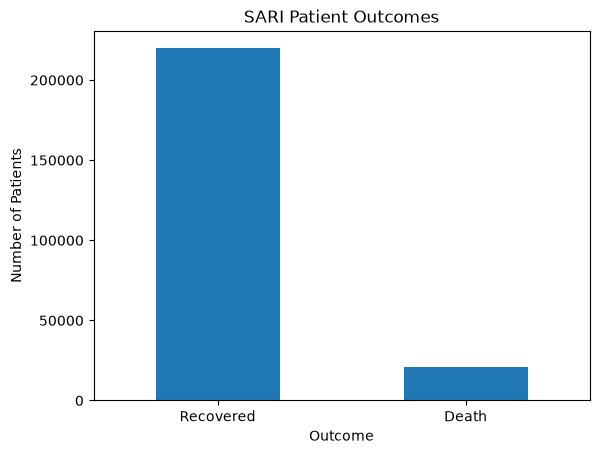

In [39]:
outcome_counts.plot(kind="bar")

plt.title("SARI Patient Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["Recovered", "Death"], rotation=0)

plt.show()

Most patients recovered
        so
Deaths are minority class
        so
Dataset is imbalanced. 

ACCURACY metrics is not sufficient to evaluate the model. we need to use F1 score, precision, recall, and AUC.



In [40]:
df_model.groupby("target_death")["age_years"].describe()

,count,mean,std,min,25%,50%,75%,max
target_death,,,,,,,,
0,219705.0,24.961569,31.872547,-0.333333,0.75,5.0,56.0,113.0
1,20730.0,64.544208,25.199377,0.000000,55.00,71.0,82.0,114.0


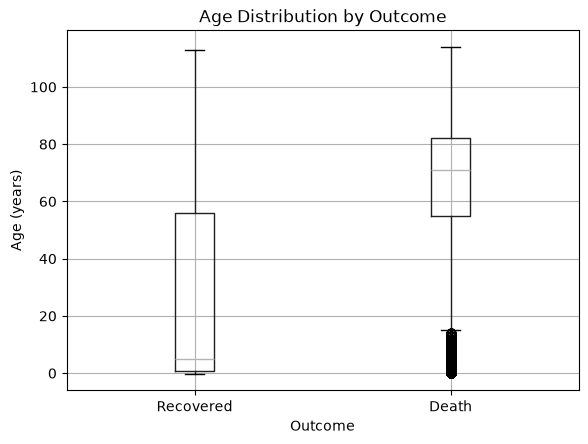

In [41]:
df_model.boxplot(
    column="age_years",
    by="target_death"
)

plt.title("Age Distribution by Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("Age (years)")
plt.xticks([1, 2], ["Recovered", "Death"])

plt.show()

In [42]:
df_model["age_group"] = pd.cut(
    df_model["age_years"],
    bins=[0, 18, 40, 60, 80, float("inf")],
    labels=["0-18", "19-40", "41-60", "61-80", "80+"],
    include_lowest=True
)

In [43]:
age_mortality = (
    df_model
    .groupby("age_group", observed=True)["target_death"]
    .mean()
    .mul(100)
    .round(2)
)

age_mortality

age_group
0-18      1.33
19-40     8.91
41-60    15.97
61-80    20.91
80+      24.77
Name: target_death, dtype: float64

WE note that the mortality rate is a function of the age of the patient, and the severity of the disease. The mortality rate is also affected by the presence of comorbidities, such as cardiovascular disease, diabetes, neurological disease, chronic lung disease, immunodeficiency, renal disease, obesity, and others which will be discovered later in the study.
overall the highest mortality rate is 80+ years old and overall as the increase in age the mortality rate increases.


0–18       low mortality

19–40      low

41–60      increasing

61–80      higher

80+        highest

In [44]:
pd.crosstab(
    df_model["CS_SEXO"],
    df_model["target_death"],
    normalize="index"
).mul(100).round(2)

target_death,0,1
CS_SEXO,,
F,91.29,8.71
I,100.00,0.00
M,91.46,8.54


DISPNEIA records dyspnoea,
FEBRE records fever,
TOSSE records chills,
GARGANTA records throat infection symptoms,
DESC_RESP respiratory discomfort,
and SATURACAO whether oxygen saturation was below 95%.   


interpretation codes: 
1 = Yes the patient has symptoms
2 = No the patient does not have symptoms
9 = Unknown

In [45]:
key_symptoms = [
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
]


for symptom in key_symptoms:
    print(f"\n--- {symptom} ---")

    result = (
        df_model[df_model[symptom].isin([1, 2])]
        .groupby(symptom)["target_death"]
        .mean()
        .mul(100)
        .round(2)
    )

    print(result)


--- FEBRE ---
FEBRE
1.0     6.47
2.0    12.57
Name: target_death, dtype: float64

--- TOSSE ---
TOSSE
1.0     6.23
2.0    18.39
Name: target_death, dtype: float64

--- DISPNEIA ---
DISPNEIA
1.0    10.54
2.0     4.84
Name: target_death, dtype: float64

--- DESC_RESP ---
DESC_RESP
1.0    9.86
2.0    6.21
Name: target_death, dtype: float64

--- SATURACAO ---
SATURACAO
1.0    11.47
2.0     4.83
Name: target_death, dtype: float64


# Conclusions on EDA:
DISPNEIA records dyspnoea(patients who had difficulty breathing), 
FEBRE records fever,
DESC_RESP respiratory discomfort,
and SATURACAO whether oxygen saturation was below 95%.   


interpretation codes: 
1 = Yes the patient has symptoms
2 = No the patient does not have symptoms
9 = Unknown


interpretation codes: 
1 = Yes the patient has symptoms
2 = No the patient does not have symptoms

The person who had dysnopea and oxygen saturation below 95% were the most likely stronger predictors for death.

# PHASE 3 TRAIN TEST SPLIT

In [46]:
baseline_features = [
    "age_years",
    "CS_SEXO",
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
]

target = "target_death"

In [47]:
symptom_features = [
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
]

for col in symptom_features:
    df_model[col] = df_model[col].replace({
        1: 1,
        2: 0,
        9: np.nan
    })

In [50]:
df_model[baseline_features].info()

<class 'pandas.DataFrame'>
Index: 240435 entries, 0 to 267985
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   age_years  240435 non-null  float64
 1   CS_SEXO    240435 non-null  str    
 2   FEBRE      215027 non-null  float64
 3   TOSSE      225073 non-null  float64
 4   DISPNEIA   212486 non-null  float64
 5   DESC_RESP  210845 non-null  float64
 6   SATURACAO  202438 non-null  float64
dtypes: float64(6), str(1)
memory usage: 14.7 MB


In [52]:
X = df_model[baseline_features].copy()
y = df_model[target].copy()

In [56]:
X.columns

Index(['age_years', 'CS_SEXO', 'FEBRE', 'TOSSE', 'DISPNEIA', 'DESC_RESP',
       'SATURACAO'],
      dtype='str')

In [60]:
X[['age_years', 'FEBRE', 'TOSSE', 'DISPNEIA', 'DESC_RESP',
       'SATURACAO']].skew()

age_years    0.696531
FEBRE       -0.868319
TOSSE       -1.870496
DISPNEIA    -1.097086
DESC_RESP   -1.156645
SATURACAO   -0.573367
dtype: float64

In [61]:
y.skew()

np.float64(2.9483674060265868)

In [62]:
y.value_counts(normalize=True)

target_death
0    0.913781
1    0.086219
Name: proportion, dtype: float64

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # Because deaths are the minority class. It keeps approximately the same mortality proportion in both train and test sets.
)


In [65]:
print(X_train.shape)
print(X_test.shape)

print(y_train.mean()) # we see the mean of both y train and ytest equal because we strattifed and via that the train/test split tries to preserve the same class proportion in both sets. 
print(y_test.mean())

(192348, 7)
(48087, 7)
0.08621872855449497
0.08621872855449497


# PHASE 4 Preprocessing pipeline

Age
→ continuous numerical

Symptoms
→ binary numerical

Sex
→ categorical

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_features = ["age_years"]

binary_features = [
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
]

categorical_features = ["CS_SEXO"]





In [67]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline([
    ("imputer", SimpleImputer(
        strategy="most_frequent",
        add_indicator=True
    ))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [68]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("bin", binary_transformer, binary_features),
    ("cat", categorical_transformer, categorical_features),
])

# PHASE 5 MODEL BUILD Baseline Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression

In [71]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        class_weight="balanced",   # Because roughly only ~9% of your patients died. Without accounting for imbalance, the model may focus too much on predicting recovery.
        max_iter=1000,
        random_state=42
    ))
])

In [72]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age_years','CS_SEXO','FEBRE',...,'DISPNEIA','DESC_RESP','SATURACAO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

# PHASE 6 Predictions

In [77]:
# the prdiction if its recovery or death
y_pred = baseline_model.predict(X_test)
y_pred # 0 is recovery and 1 is death

array([0, 1, 0, ..., 0, 0, 0], shape=(48087,))

In [78]:
# The probability of death 
y_prob = baseline_model.predict_proba(X_test)[:, 1] # identifying the probability of death
y_prob

array([0.20374818, 0.56822171, 0.4209123 , ..., 0.17594404, 0.11463386,
       0.24270848], shape=(48087,))

# PHASE 7 EVALUATION

In [79]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
)

In [80]:
print(
    "AUROC:",
    round(roc_auc_score(y_test, y_prob), 3)
)

print(
    "AUPRC:",
    round(average_precision_score(y_test, y_prob), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred), 3)
)

AUROC: 0.844
AUPRC: 0.304
Recall: 0.821
Precision: 0.233


In [81]:
print(confusion_matrix(y_test, y_pred))

[[32743 11198]
 [  741  3405]]


In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85     43941
           1       0.23      0.82      0.36      4146

    accuracy                           0.75     48087
   macro avg       0.61      0.78      0.60     48087
weighted avg       0.91      0.75      0.80     48087



AUROC
How well can the model separate higher-risk
from lower-risk patients?

AUPRC
How well does it identify the minority/death class?

Recall / Sensitivity
Of all patients who actually died,
how many did we detect?

Precision
Of patients we predicted as high-risk/death,
how many actually died?

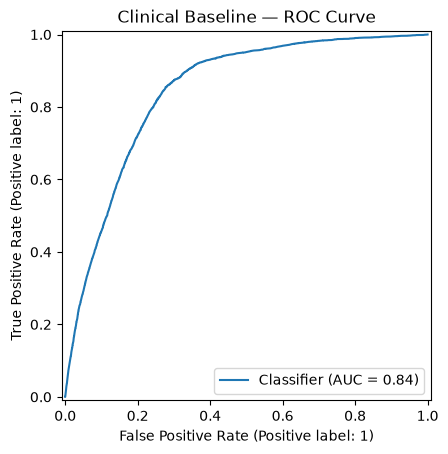

In [83]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Clinical Baseline — ROC Curve")
plt.show()

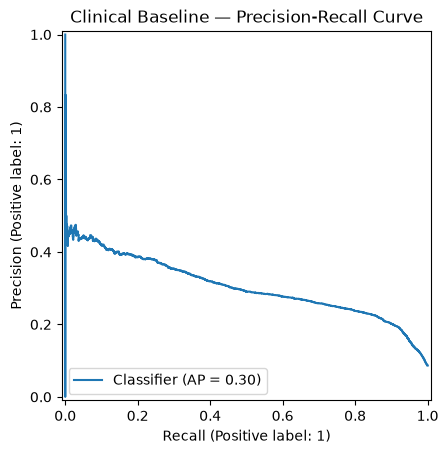

In [84]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Clinical Baseline — Precision-Recall Curve")
plt.show()

# XGBOOST

In [85]:
from xgboost import XGBClassifier

In [86]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

scale_pos_weight

np.float64(10.598408104196816)

In [87]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [88]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age_years','CS_SEXO','FEBRE',...,'DISPNEIA','DESC_RESP','SATURACAO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

In [89]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [90]:
print("AUROC:", round(roc_auc_score(y_test, xgb_prob), 3))
print("AUPRC:", round(average_precision_score(y_test, xgb_prob), 3))
print("Recall:", round(recall_score(y_test, xgb_pred), 3))
print("Precision:", round(precision_score(y_test, xgb_pred), 3))

print(confusion_matrix(y_test, xgb_pred))

AUROC: 0.851
AUPRC: 0.318
Recall: 0.867
Precision: 0.223
[[31422 12519]
 [  550  3596]]


XGBOOST MODEL correctly detects 86.7% of deaths, missing only 550 of 4,146 deaths in the test set.

# CONCLUSION :

 We first built an interpretable logistic-regression baseline using admission-time clinical variables such as age, sex, dyspnoea, respiratory distress and low oxygen saturation. 

It achieved an AUROC of 0.844 and AUPRC of 0.304, with 82.1% sensitivity for mortality.  

I then tested XGBoost to capture nonlinear relationships. It slightly improved discrimination to an AUROC of 0.851 and AUPRC of 0.318, while sensitivity increased to 86.7%. This means the model identified most patients who eventually died.  
However, precision was only 22.3%, so there was a considerable false-positive burden. I therefore see this as a strong screening baseline rather than a clinically deployable model. The next question is whether adding another modality, such as radiological information, can improve precision and overall discrimination while maintaining high sensitivity.”

The 4 things  to emphasize are:
- Death is only ~8.6% of the cohort, so accuracy is misleading.
- AUROC 0.851 → good ability to separate higher- and lower-risk patients.
- Recall 86.7% → it detected most patients who died.
- Precision 22.3% → many false alarms remain, giving a clear reason to improve the model.


Model performance:
“XGBoost was modestly better than logistic regression in AUROC, AUPRC and sensitivity, so I selected it as the stronger clinical baseline. But the improvement was modest, which also suggests that the current clinical features already contain substantial signal.”

final thoughts
“My goal was not simply to maximize performance; it was to establish a clinically sensible baseline that the multimodal model must outperform.”

# PHASE 8: Model 2 > Enhanced Clinical Model = baseline + comorbidities

In [91]:
# Comorbidity features
comorbidity_features = [
    "CARDIOPATI",
    "DIABETES",
    "PNEUMOPATI",
    "RENAL",
    "IMUNODEPRE",
    "ASMA",
    "NEUROLOGIC",
    "OBESIDADE",
]

# Recode:
# 1 = Yes
# 2 = No
# 9 = Unknown
for col in comorbidity_features:
    df_model[col] = df_model[col].replace({
        1: 1,
        2: 0,
        9: np.nan
    })

In [93]:
enhanced_features = baseline_features + comorbidity_features

X_enhanced = df_model[enhanced_features].copy()
y_enhanced = df_model["target_death"].copy()

In [95]:
X2_train = X_enhanced.loc[X_train.index]
X2_test = X_enhanced.loc[X_test.index]

y2_train = y_enhanced.loc[y_train.index]
y2_test = y_enhanced.loc[y_test.index]


""" same patients
same train/test split
same target
same algorithm

ONLY DIFFERENCE:
comorbidities features added"""

' same patients\nsame train/test split\nsame target\nsame algorithm\n\nONLY DIFFERENCE:\ncomorbidities features added'

In [96]:
numeric_features_2 = [
    "age_years"
]

binary_features_2 = [
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
] + comorbidity_features

categorical_features_2 = [
    "CS_SEXO"
]

In [97]:
preprocessor_2 = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features_2
    ),

    (
        "bin",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=True
                )
            )
        ]),
        binary_features_2
    ),

    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        categorical_features_2
    )
])

In [98]:
enhanced_model = Pipeline([
    ("preprocessor", preprocessor_2),

    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

In [99]:
enhanced_model.fit(X2_train, y2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age_years','CS_SEXO','FEBRE',...,'ASMA','NEUROLOGIC','OBESIDADE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [100]:
enhanced_pred = enhanced_model.predict(X2_test)

enhanced_prob = enhanced_model.predict_proba(
    X2_test
)[:, 1]

In [101]:
print(
    "AUROC:",
    round(roc_auc_score(y2_test, enhanced_prob), 3)
)

print(
    "AUPRC:",
    round(average_precision_score(y2_test, enhanced_prob), 3)
)

print(
    "Recall:",
    round(recall_score(y2_test, enhanced_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y2_test, enhanced_pred), 3)
)

print(
    confusion_matrix(y2_test, enhanced_pred)
)

AUROC: 0.857
AUPRC: 0.329
Recall: 0.876
Precision: 0.226
[[31510 12431]
 [  515  3631]]


### Correlations

In [102]:
df_model["male"] = df_model["CS_SEXO"].map({
    "M": 1,
    "F": 0
})

In [103]:
correlation_features = [
    "target_death",
    "age_years",
    "male",

    # Symptoms
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",

    # Comorbidities
    "CARDIOPATI",
    "DIABETES",
    "PNEUMOPATI",
    "RENAL",
    "IMUNODEPRE",
    "ASMA",
    "NEUROLOGIC",
    "OBESIDADE",
]

corr_df = df_model[correlation_features].copy()

In [104]:
target_corr = (
    corr_df
    .corr()["target_death"]
    .drop("target_death")
    .sort_values(key=abs, ascending=False)
)

target_corr

age_years     0.334010
TOSSE        -0.162188
ASMA         -0.153018
CARDIOPATI    0.112061
SATURACAO     0.111119
FEBRE        -0.101499
DISPNEIA      0.087155
DIABETES      0.087064
RENAL         0.057773
DESC_RESP     0.055399
PNEUMOPATI    0.046180
IMUNODEPRE    0.037478
NEUROLOGIC    0.033269
OBESIDADE     0.021629
male         -0.002937
Name: target_death, dtype: float64

In [106]:
corr_df.corr()

,target_death,age_years,male,FEBRE,TOSSE,DISPNEIA,DESC_RESP,SATURACAO,CARDIOPATI,DIABETES,PNEUMOPATI,RENAL,IMUNODEPRE,ASMA,NEUROLOGIC,OBESIDADE
target_death,1.000000,0.334010,-0.002937,-0.101499,-0.162188,0.087155,0.055399,0.111119,0.112061,0.087064,0.046180,0.057773,0.037478,-0.153018,0.033269,0.021629
age_years,0.334010,1.000000,-0.094302,-0.218338,-0.161812,0.075121,-0.095909,0.087788,0.486955,0.386949,0.164886,0.115573,-0.033016,-0.368604,-0.008737,0.078501
male,-0.002937,-0.094302,1.000000,0.031133,0.011570,0.000011,0.024557,-0.004965,-0.053296,-0.051905,-0.010031,0.041866,0.029816,-0.024409,0.015162,-0.062738
FEBRE,-0.101499,-0.218338,0.031133,1.000000,0.197459,-0.012956,0.034922,0.000058,-0.038991,-0.021449,-0.031895,0.002914,0.091350,0.050798,0.114742,-0.008898
TOSSE,-0.162188,-0.161812,0.011570,0.197459,1.000000,0.099607,0.097577,0.038420,0.003984,-0.004946,0.059350,0.003518,0.042533,0.150018,0.003210,0.005819
DISPNEIA,0.087155,0.075121,0.000011,-0.012956,0.099607,1.000000,0.352132,0.323506,0.108645,0.060123,0.148573,0.021868,0.021221,0.104445,0.000116,0.063225
DESC_RESP,0.055399,-0.095909,0.024557,0.034922,0.097577,0.352132,1.000000,0.379528,0.022904,-0.005248,0.077391,-0.001963,0.001715,0.121537,0.047850,0.034342
SATURACAO,0.111119,0.087788,-0.004965,0.000058,0.038420,0.323506,0.379528,1.000000,0.095568,0.046968,0.124767,0.011175,0.016029,0.090678,0.077165,0.052835
CARDIOPATI,0.112061,0.486955,-0.053296,-0.038991,0.003984,0.108645,0.022904,0.095568,1.000000,0.328127,0.122232,0.135404,-0.040202,-0.192780,0.004901,0.103505
DIABETES,0.087064,0.386949,-0.051905,-0.021449,-0.004946,0.060123,-0.005248,0.046968,0.328127,1.000000,0.027330,0.134684,-0.026449,-0.133776,-0.028201,0.149826


In [107]:
df_model.groupby(
    df_model["ASMA"].isna()
)["target_death"].agg(["count", "mean"])

,count,mean
ASMA,,
False,73775,0.151162
True,166660,0.057470



Exploratory association analysis showed age as the strongest individual correlate of mortality. 

Indicators of respiratory compromise such as low oxygen saturation and dyspnoea were positively associated with mortality, 

while some symptoms such as cough and fever showed negative crude associations.


# PHASE 9 : Model 3 

SAME 2,855 PATIENTS has been used because only 2855 patients have xray results from the total pouplation.
        │
        ├──────── MODEL A ────────┐
        │                         │
        │ Age                     │
        │ Sex                     │
        │ Symptoms                │
        │ Comorbidities           │
        │                         ↓
        │                  Predict death
        │
        └──────── MODEL B ────────┐
                                  │
             Age                  │
             Sex                  │
             Symptoms             │
             Comorbidities        │
             +                    │
             X-RAY RESULT         │
                                  ↓
                           Predict death

RAIOX_RES stores the chest X-ray finding:
1 Normal, 2 Interstitial infiltrate, 3 Consolidation, 4 Mixed, 5 Other, 6 Not performed, 9 Unknown.

In [108]:
df_model["RAIOX_RES"].value_counts(dropna=False)

RAIOX_RES
NaN    71131
6.0    44059
2.0    41885
5.0    27123
1.0    22162
9.0    16280
3.0    11930
4.0     5865
Name: count, dtype: int64

In [109]:
df_model["RAIOX_RES"].value_counts(
    dropna=False,
    normalize=True
).mul(100).round(2)

RAIOX_RES
NaN    29.58
6.0    18.32
2.0    17.42
5.0    11.28
1.0     9.22
9.0     6.77
3.0     4.96
4.0     2.44
Name: proportion, dtype: float64

In [110]:
df_model["DT_RAIOX_dt"] = pd.to_datetime(
    df_model["DT_RAIOX"],
    dayfirst=True,
    errors="coerce"
)

df_model["DT_INTERNA_dt"] = pd.to_datetime(
    df_model["DT_INTERNA"],
    dayfirst=True,
    errors="coerce"
)

df_model["xray_delay_days"] = (
    df_model["DT_RAIOX_dt"]
    - df_model["DT_INTERNA_dt"]
).dt.days

/var/folders/35/n1qx6qpn40ngzm9t29t8ybqm0000gn/T/ipykernel_95054/1335745121.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S.%f%z format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_model["DT_RAIOX_dt"] = pd.to_datetime(


In [111]:
df_model["xray_delay_days"].describe()

count    3.926200e+04
mean     1.131415e+02
std      1.235966e+04
min     -6.486400e+04
25%     -8.900000e+01
50%      0.000000e+00
75%      9.500000e+01
max      1.891373e+06
Name: xray_delay_days, dtype: float64

In [112]:
df_model["xray_delay_days"].value_counts().sort_index().head(20)

xray_delay_days
-64864.0      1
-396.0        1
-327.0        1
-326.0        1
-325.0        8
-324.0       67
-323.0       14
-322.0        2
-321.0        3
-310.0        1
-301.0        1
-299.0        1
-298.0        3
-297.0        6
-296.0       15
-295.0       84
-294.0      129
-293.0       18
-292.0        7
-291.0        5
Name: count, dtype: int64

In [113]:
df_model["xray_delay_days"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    3.926200e+04
mean     1.131415e+02
std      1.235966e+04
min     -6.486400e+04
1%      -2.670000e+02
5%      -2.100000e+02
25%     -8.900000e+01
50%      0.000000e+00
75%      9.500000e+01
95%      2.360000e+02
99%      2.950000e+02
max      1.891373e+06
Name: xray_delay_days, dtype: float64

In [114]:
df_model.loc[
    df_model["xray_delay_days"].between(-7, 14),
    "xray_delay_days"
].value_counts().sort_index()

xray_delay_days
-6.0        2
-5.0        6
-4.0       10
-3.0       15
-2.0       47
-1.0      225
 0.0     2331
 1.0      299
 2.0       81
 3.0       46
 4.0       31
 5.0       18
 6.0       16
 7.0       17
 8.0        6
 9.0        5
 10.0      10
 11.0       4
 12.0       2
 13.0       8
 14.0       6
Name: count, dtype: int64

In [ ]:
windows = {
    "same day": (0, 0),
    "admission ±1 day": (-1, 1),
    "admission ±3 days": (-3, 3),
    "admission to +1 day": (0, 1),
    "admission to +3 days": (0, 3),
}

for name, (low, high) in windows.items():
    n = df_model["xray_delay_days"].between(low, high).sum()
    print(name, ":", n)





same day : 2331
admission ±1 day : 2855
admission ±3 days : 3044
admission to +1 day : 2630
admission to +3 days : 2757


In [116]:
df_model.loc[
    df_model["xray_delay_days"].abs() > 30,
    ["DT_INTERNA", "DT_RAIOX", "xray_delay_days", "RAIOX_RES"]
].head(20)

,DT_INTERNA,DT_RAIOX,xray_delay_days,RAIOX_RES
0,2024-09-10T00:00:00.000Z,2024-08-29T00:00:00.000Z,-41.0,3.0
25,2024-07-05T00:00:00.000Z,2024-07-05T00:00:00.000Z,59.0,2.0
41,2024-05-01T00:00:00.000Z,2024-04-28T00:00:00.000Z,114.0,5.0
67,2024-12-08T00:00:00.000Z,2024-12-08T00:00:00.000Z,118.0,2.0
96,2024-05-01T00:00:00.000Z,2024-05-03T00:00:00.000Z,119.0,2.0
104,2024-08-06T00:00:00.000Z,2024-08-06T00:00:00.000Z,59.0,1.0
145,2024-03-12T00:00:00.000Z,2024-03-17T00:00:00.000Z,-261.0,4.0
155,2024-10-02T00:00:00.000Z,2024-10-02T00:00:00.000Z,235.0,5.0
174,2024-09-12T00:00:00.000Z,2024-09-12T00:00:00.000Z,-88.0,3.0
176,2024-08-06T00:00:00.000Z,2024-08-06T00:00:00.000Z,59.0,5.0


In [117]:
xray_cohort = df_model[
    df_model["RAIOX_RES"].isin([1, 2, 3, 4, 5])
    & df_model["xray_delay_days"].between(-1, 1)
].copy()

In [ ]:
xray_cohort = df_model[
    df_model["RAIOX_RES"].isin([1, 2, 3, 4, 5])#since we select RAIOX_RES codes 1–5 mean an actual reported X-ray result; 6 is not performed and 9 is unknown.
    & df_model["xray_delay_days"].between(-1, 1)
].copy()

print("Patients:", len(xray_cohort))
print(xray_cohort["target_death"].value_counts())
print(
    xray_cohort["target_death"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Patients: 2855
target_death
0    2681
1     174
Name: count, dtype: int64
target_death
0    93.91
1     6.09
Name: proportion, dtype: float64


In [119]:
xray_labels = {
    1: "Normal",
    2: "Interstitial infiltrate",
    3: "Consolidation",
    4: "Mixed",
    5: "Other"
}

print(
    xray_cohort["RAIOX_RES"]
    .map(xray_labels)
    .value_counts()
)

RAIOX_RES
Interstitial infiltrate    1133
Other                       647
Normal                      604
Consolidation               313
Mixed                       158
Name: count, dtype: int64


In [120]:
xray_mortality = (
    xray_cohort
    .assign(
        xray_result=xray_cohort["RAIOX_RES"].map(xray_labels)
    )
    .groupby("xray_result")["target_death"]
    .agg(["count", "mean"])
)

xray_mortality["mortality_percent"] = (
    xray_mortality["mean"] * 100
).round(2)

xray_mortality

,count,mean,mortality_percent
xray_result,,,
Consolidation,313,0.089457,8.95
Interstitial infiltrate,1133,0.064431,6.44
Mixed,158,0.132911,13.29
Normal,604,0.028146,2.81
Other,647,0.054096,5.41


In [121]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    confusion_matrix
)

In [123]:
#splitting thee radiology cohort (2855 patients) into train and test sets
train_idx, test_idx = train_test_split(
    xray_cohort.index,
    test_size=0.20,
    random_state=42,
    stratify=xray_cohort["target_death"]
)

y_train_r = xray_cohort.loc[train_idx, "target_death"]
y_test_r = xray_cohort.loc[test_idx, "target_death"]

print(y_train_r.value_counts())
print(y_test_r.value_counts())

target_death
0    2145
1     139
Name: count, dtype: int64
target_death
0    536
1     35
Name: count, dtype: int64


In [125]:
#recalculate the class weight because this cohort has a different mortality prevalence:
neg = (y_train_r == 0).sum()
pos = (y_train_r == 1).sum()

scale_pos_weight_r = neg / pos

print(scale_pos_weight_r)

15.431654676258994


In [126]:
clinical_features = enhanced_features

X2R_train = xray_cohort.loc[
    train_idx,
    clinical_features
]

X2R_test = xray_cohort.loc[
    test_idx,
    clinical_features
]

In [127]:
numeric_features_r = [
    "age_years"
]

binary_features_r = [
    "FEBRE",
    "TOSSE",
    "DISPNEIA",
    "DESC_RESP",
    "SATURACAO",
] + comorbidity_features

categorical_features_r = [
    "CS_SEXO"
]

In [128]:
clinical_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features_r
    ),

    (
        "bin",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=True
                )
            )
        ]),
        binary_features_r
    ),

    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features_r
    )
])

In [129]:
clinical_xray_cohort_model = Pipeline([
    ("preprocessor", clinical_preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_r,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

clinical_xray_cohort_model.fit(
    X2R_train,
    y_train_r
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age_years','CS_SEXO','FEBRE',...,'ASMA','NEUROLOGIC','OBESIDADE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

In [130]:
pred_2r = clinical_xray_cohort_model.predict(X2R_test)

prob_2r = clinical_xray_cohort_model.predict_proba(
    X2R_test
)[:, 1]

print("MODEL 2R — Clinical only")
print("AUROC:", round(roc_auc_score(y_test_r, prob_2r), 3))
print("AUPRC:", round(average_precision_score(y_test_r, prob_2r), 3))
print("Recall:", round(recall_score(y_test_r, pred_2r), 3))
print("Precision:", round(precision_score(y_test_r, pred_2r), 3))
print(confusion_matrix(y_test_r, pred_2r))

MODEL 2R — Clinical only
AUROC: 0.784
AUPRC: 0.222
Recall: 0.6
Precision: 0.188
[[445  91]
 [ 14  21]]


# model 3 addng the radiological data 

In [131]:
multimodal_features = enhanced_features + [
    "RAIOX_RES"
]

X3_train = xray_cohort.loc[
    train_idx,
    multimodal_features
]

X3_test = xray_cohort.loc[
    test_idx,
    multimodal_features
]

In [132]:
categorical_features_3 = [
    "CS_SEXO",
    "RAIOX_RES"
]

In [135]:
multimodal_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features_r
    ),

    (
        "bin",
        Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                    add_indicator=True
                )
            )
        ]),
        binary_features_r
    ),

    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features_3
    )
])

In [137]:
multimodal_model = Pipeline([
    ("preprocessor", multimodal_preprocessor),

    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_r,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

multimodal_model.fit(
    X3_train,
    y_train_r
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['age_years','CS_SEXO','FEBRE',...,'NEUROLOGIC','OBESIDADE','RAIOX_RES']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrou

In [138]:
pred_3 = multimodal_model.predict(X3_test)

prob_3 = multimodal_model.predict_proba(
    X3_test
)[:, 1]

print("MODEL 3 — Clinical + Radiology")
print("AUROC:", round(roc_auc_score(y_test_r, prob_3), 3))
print("AUPRC:", round(average_precision_score(y_test_r, prob_3), 3))
print("Recall:", round(recall_score(y_test_r, pred_3), 3))
print("Precision:", round(precision_score(y_test_r, pred_3), 3))
print(confusion_matrix(y_test_r, pred_3))

MODEL 3 — Clinical + Radiology
AUROC: 0.801
AUPRC: 0.206
Recall: 0.543
Precision: 0.211
[[465  71]
 [ 16  19]]


Model 2R: same 2,855 patients, clinical only.



Model 3 : same 2,855 patients, clinical + X-ray

# ANAOMALY DETECTION SURVELLIENCE

In [139]:
df_model["DT_SIN_PRI_dt"] = pd.to_datetime(
    df_model["DT_SIN_PRI"],
    dayfirst=True,
    errors="coerce"
)

/var/folders/35/n1qx6qpn40ngzm9t29t8ybqm0000gn/T/ipykernel_95054/3352197751.py:1: UserWarning: Parsing dates in %Y-%m-%dT%H:%M:%S.%f%z format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_model["DT_SIN_PRI_dt"] = pd.to_datetime(


In [140]:
df_model["DT_SIN_PRI_dt"].describe()

count                              240435
mean     2024-06-23 18:20:13.790005+00:00
min             2023-12-31 00:00:00+00:00
25%             2024-04-09 00:00:00+00:00
50%             2024-06-13 00:00:00+00:00
75%             2024-09-08 00:00:00+00:00
max             2024-12-28 00:00:00+00:00
Name: DT_SIN_PRI_dt, dtype: object

In [141]:
df_model["week"] = (
    df_model["DT_SIN_PRI_dt"]
    .dt.to_period("W")
    .apply(lambda x: x.start_time)
)

/var/folders/35/n1qx6qpn40ngzm9t29t8ybqm0000gn/T/ipykernel_95054/699875566.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W")


In [142]:
weekly_cases = (
    df_model
    .groupby("week")
    .size()
    .reset_index(name="cases")
)

weekly_cases.head()

,week,cases
0,2023-12-25,389
1,2024-01-01,2858
2,2024-01-08,2471
3,2024-01-15,2555
4,2024-01-22,2550


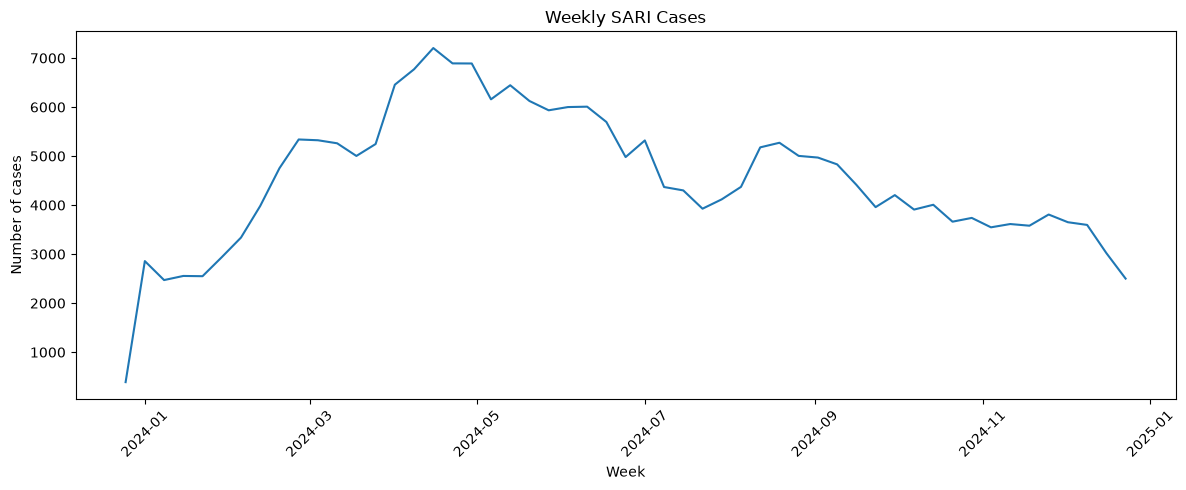

In [143]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_cases["week"],
    weekly_cases["cases"]
)

plt.title("Weekly SARI Cases")
plt.xlabel("Week")
plt.ylabel("Number of cases")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [144]:
weekly_cases = weekly_cases.sort_values("week").copy()

weekly_cases["baseline_mean"] = (
    weekly_cases["cases"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

weekly_cases["baseline_std"] = (
    weekly_cases["cases"]
    .shift(1)
    .rolling(window=4)
    .std()
)

weekly_cases["z_score"] = (
    weekly_cases["cases"] - weekly_cases["baseline_mean"]
) / weekly_cases["baseline_std"]

weekly_cases["alert"] = weekly_cases["z_score"] > 2

In [145]:
weekly_cases.loc[
    weekly_cases["alert"],
    ["week", "cases", "baseline_mean", "z_score"]
]

,week,cases,baseline_mean,z_score
6,2024-02-05,3338,2628.50,3.380348
7,2024-02-12,3983,2845.25,3.030598
8,2024-02-19,4753,3202.25,2.534328
14,2024-04-01,6456,5208.25,8.859714
33,2024-08-12,5178,4179.25,5.012272
48,2024-11-25,3808,3620.00,2.240319


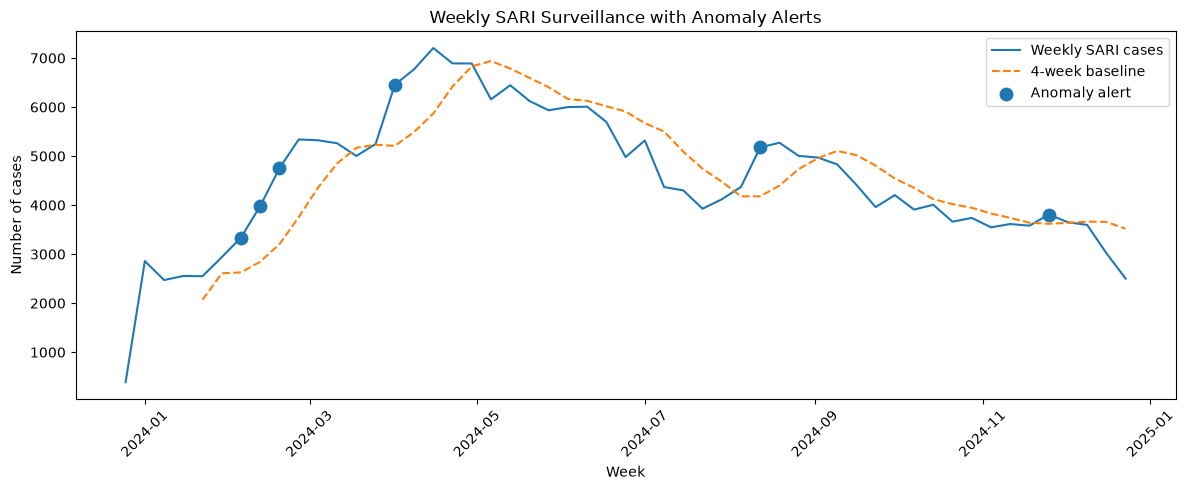

In [146]:
plt.figure(figsize=(12, 5))

plt.plot(
    weekly_cases["week"],
    weekly_cases["cases"],
    label="Weekly SARI cases"
)

plt.plot(
    weekly_cases["week"],
    weekly_cases["baseline_mean"],
    linestyle="--",
    label="4-week baseline"
)

alerts = weekly_cases[weekly_cases["alert"]]

plt.scatter(
    alerts["week"],
    alerts["cases"],
    s=80,
    label="Anomaly alert"
)

plt.title("Weekly SARI Surveillance with Anomaly Alerts")
plt.xlabel("Week")
plt.ylabel("Number of cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [147]:
weekly_cases.to_csv(
    "../data/weekly_surveillance.csv",
    index=False
)

In [ ]:
import os

os.makedirs("../outputs", exist_ok=True)

weekly_cases.to_csv(
    "../outputs/weekly_surveillance.csv",
    index=False
)

In [149]:
import os
import pandas as pd

os.makedirs("../outputs", exist_ok=True)

In [150]:
model_results = pd.DataFrame({
    "Model": [
        "Clinical baseline",
        "Clinical + comorbidities",
        "Clinical only — X-ray cohort",
        "Clinical + radiology"
    ],

    "AUROC": [
        0.851,
        0.857,
        0.784,
        0.801
    ],

    "AUPRC": [
        0.318,
        0.329,
        0.222,
        0.206
    ],

    "Recall": [
        0.867,
        0.876,
        0.600,
        0.543
    ],

    "Precision": [
        0.223,
        0.226,
        0.188,
        0.211
    ]
})

model_results.to_csv(
    "../outputs/model_results.csv",
    index=False
)

In [151]:
weekly_cases.to_csv(
    "../outputs/weekly_surveillance.csv",
    index=False
)